In [1]:
#Reference: https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
pd.set_option('display.max_rows', 20000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 500)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import sys
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder \
    .master("local") \
    .appName("Exercise3") \
    .getOrCreate ()

df = spark.read.csv('exampleData.csv', header = True)

In [3]:
df.dtypes

[('_c0', 'string'),
 ('dateTime', 'string'),
 ('indicator_rain', 'string'),
 ('precipitation', 'string'),
 ('indicator_temp', 'string'),
 ('air_temperature', 'string'),
 ('indicator_wetb', 'string'),
 ('wetb', 'string'),
 ('dewpt', 'string'),
 ('vappr', 'string'),
 ('relative_humidity', 'string'),
 ('msl', 'string'),
 ('indicator_wdsp', 'string'),
 ('wind_speed', 'string'),
 ('indicator_wddir', 'string'),
 ('wind_from_direction', 'string')]

#### 3) Indexing the data with StringIndexer

What StringIndexer does:

The StringIndexer is a transformer in Spark ML that is used to encode a column of strings (categorical data) into a column of numerical labels. It works by:

Identifying unique strings: It scans the input column and identifies all the unique string values.
Assigning numerical indices: It assigns a unique integer index to each unique string. The indexing is typically done based on the frequency of the strings, with the most frequent string getting the index 0, the next most frequent getting 1, and so on.
Transforming the column: It creates a new column where each original string value is replaced by its corresponding numerical index.
Why is this useful?

Many machine learning algorithms can only work with numerical input data. If you have categorical features (represented as strings) in your dataset, you need to convert them into a numerical format before you can use them to train a machine learning model. StringIndexer is a common and effective way to achieve this.

Example:

Let's say you have a DataFrame with a column named "color" containing values like "red", "blue", and "green". After applying StringIndexer to this column, you might get a new column (e.g., "color_indexed") where:

"red" is mapped to 0
"blue" is mapped to 1
"green" is mapped to 2

In [4]:
from pyspark.ml.feature import StringIndexer
indexer = StringIndexer(inputCol="dateTime" ,outputCol="indexedTime") 
indexed = indexer.fit(df).transform(df) 
#indexed.show(vertical=True)
indexed.show(n=1, vertical=True)  # Show the first 10 rows vertically
indexed.show(n=1, vertical=True)   # Show the first 5 rows vertically
#indexed.show(n=indexed.count(), vertical=True) # Show all rows (if you know it's not too large)

-RECORD 0--------------------------------
 _c0                 | 14                
 dateTime            | 01-jan-1990 00:00 
 indicator_rain      | 0                 
 precipitation       | 0.3               
 indicator_temp      | 0                 
 air_temperature     | 9.1               
 indicator_wetb      | 0                 
 wetb                | 9.0               
 dewpt               | 8.9               
 vappr               | 11.4              
 relative_humidity   | 99                
 msl                 | 1006.7            
 indicator_wdsp      | 2                 
 wind_speed          | 7                 
 indicator_wddir     | 2                 
 wind_from_direction | 190               
 indexedTime         | 2667.0            
only showing top 1 row

-RECORD 0--------------------------------
 _c0                 | 14                
 dateTime            | 01-jan-1990 00:00 
 indicator_rain      | 0                 
 precipitation       | 0.3               
 indicator

In [41]:
indexed.select("dateTime", "indexedTime").show(10)

+-----------------+-----------+
|         dateTime|indexedTime|
+-----------------+-----------+
|01-jan-1990 00:00|     2667.0|
|01-jan-1990 01:00|     2668.0|
|01-jan-1990 02:00|     2669.0|
|01-jan-1990 03:00|     2670.0|
|01-jan-1990 04:00|     2671.0|
|01-jan-1990 05:00|     2672.0|
|01-jan-1990 06:00|     2673.0|
|01-jan-1990 07:00|     2674.0|
|01-jan-1990 08:00|     2675.0|
|01-jan-1990 09:00|     2676.0|
+-----------------+-----------+
only showing top 10 rows



In [42]:
indexed.show(5)  # Show the first 10 rows
indexed.show(3, vertical=True)  # Show the first 5 rows vertically

+---+-----------------+--------------+-------------+--------------+---------------+--------------+----+-----+-----+-----------------+------+--------------+----------+---------------+-------------------+-----------+
|_c0|         dateTime|indicator_rain|precipitation|indicator_temp|air_temperature|indicator_wetb|wetb|dewpt|vappr|relative_humidity|   msl|indicator_wdsp|wind_speed|indicator_wddir|wind_from_direction|indexedTime|
+---+-----------------+--------------+-------------+--------------+---------------+--------------+----+-----+-----+-----------------+------+--------------+----------+---------------+-------------------+-----------+
| 14|01-jan-1990 00:00|             0|          0.3|             0|            9.1|             0| 9.0|  8.9| 11.4|               99|1006.7|             2|         7|              2|                190|     2667.0|
| 15|01-jan-1990 01:00|             0|          0.2|             0|            8.2|             0| 7.4|  6.4|  9.7|               89|1006.7|

#### Can we use any other alternative approach than StringIndexer? If yes, what is the main advantage?

**1. One-Hot Encoding (using OneHotEncoder or OneHotEncoderModel):**

How it works: For each unique category in a column, a new binary (0 or 1) column is created. If a row belongs to a particular category, the corresponding binary column will have a 1, and all other binary columns for that feature will have 0.   
Main Advantage:
No ordinality implied: Unlike StringIndexer, one-hot encoding does not impose any artificial ordinal relationship between the categories. This is crucial for nominal categorical features where there is no inherent order (e.g., colors, city names). Many machine learning algorithms can misinterpret the numerical order created by StringIndexer as having significance.

**2. VectorAssembler with Manual Encoding:**

How it works: You can manually create binary or other numerical representations for your categories using Spark SQL functions (e.g., when, otherwise) and then use VectorAssembler to combine these numerical columns into a single feature vector.
Main Advantage:
Fine-grained control: This approach gives you complete control over how each category is encoded. You might have domain-specific knowledge that suggests a particular numerical representation is more meaningful.
Handling specific scenarios: Useful for creating custom encodings, handling rare categories in specific ways, or combining information from multiple categorical columns into a single numerical representation.

**3. HashingTF (Hashing Term Frequency):**

How it works: Primarily used for text data, HashingTF maps a set of terms to their term frequencies in a fixed-size vector (the "feature space") using a hashing function.
Main Advantage (when applicable to categorical data):
Dimensionality reduction for high-cardinality features: If you have categorical features with a very large number of unique values, one-hot encoding can lead to a very high-dimensional sparse matrix, which can be computationally expensive. Hashing can reduce the dimensionality.   
Handles unseen categories (to some extent): New, unseen categories during testing will still be hashed into one of the existing buckets. However, this can also lead to collisions (different categories being mapped to the same index).

**4. Embedding Techniques (more advanced, often with deep learning):**

How it works: These techniques learn dense, low-dimensional vector representations (embeddings) for categorical features based on their co-occurrence patterns or relationships within the data. Libraries like Word2Vec (though primarily for text) or custom neural network embedding layers can be used.
Main Advantage:
Captures semantic relationships: Embeddings can capture more complex relationships and similarities between categories than simple one-hot encoding or indexing. For example, embeddings for different car brands might be closer in the vector space than embeddings for completely unrelated categories.   
Dimensionality reduction: Embeddings typically have a much lower dimensionality than one-hot encoded vectors, which can improve model performance and reduce computational costs. 

**5. Tree-Based Models (directly handle categorical features in some implementations):**

How it works: Some tree-based algorithms (like those in libraries outside of standard Spark MLlib, or certain configurations) can directly handle categorical features without requiring explicit numerical encoding. They can split nodes based on the categories themselves.   
Main Advantage:
No need for explicit encoding: Simplifies the preprocessing pipeline.
Potential for better performance: By directly considering categorical splits, the model might be able to learn more nuanced relationships without the potential information loss from numerical encoding.
Note: While Spark MLlib's decision trees and random forests work best with numerical features, the underlying logic can conceptually handle categorical splits. However, the standard practice in Spark MLlib is to encode categorical features numerically before using these models. 

**When to choose an alternative over StringIndexer:**

Nominal categorical features: For features without any inherent order (e.g., colors, product categories), one-hot encoding is generally preferred to avoid misleading the model with artificial ordinality.   
High-cardinality categorical features: If a categorical feature has a very large number of unique values, hashing or embedding techniques might be considered to manage dimensionality. Be mindful of potential collisions with hashing.
Domain-specific encoding: If you have specific reasons to represent categories with particular numerical values, manual encoding offers the most flexibility.
Capturing complex relationships: For richer representations that capture semantic similarities, embedding techniques are the way to go (often in conjunction with deep learning models).

#### 4) Change and select the types of parameters to vectorize the data for further training

In [5]:
# Change the data types of parameters to correct ones to vectorize
parsed_data = indexed.selectExpr(
    "cast(dateTime as string) as dateTime",
    "cast(relative_humidity as float) as relative_humidity",
    "cast(wind_speed as float) as wind_speed",
    "cast(indexedTime as double) as indexedTime",
    "cast(air_temperature as float) as label",
    "cast(msl as float) as msl"
)

#### 5) Vectorize data and generate features using Spark MLlib’s Vector Assembler

In [6]:
from pyspark.ml.feature import VectorAssembler

vectorAssembler = VectorAssembler(
    inputCols=['relative_humidity', 'wind_speed', 'indexedTime', 'msl'],
    handleInvalid="skip",
    outputCol='features'
)

vectorized_df = vectorAssembler.transform(parsed_data)
dataset = vectorized_df.select("features", "label")

##### What does parameter → HandleInvalid do in the vector assembler?

The handleInvalid parameter accepts one of the following string values:

`skip` (default): When handleInvalid is set to "skip", any row in the input DataFrame that contains a NaN, Infinity, or -Infinity value in any of the inputCols specified for the VectorAssembler will be entirely skipped (i.e., not included) in the output features vector column of the transformed DataFrame. This is often the safest and most common approach to avoid issues with machine learning algorithms that cannot handle these special numerical values.

`error`: If handleInvalid is set to "error", the VectorAssembler will throw an exception if it encounters any NaN, Infinity, or -Infinity value in the inputCols of any row. This option is useful when you want to explicitly know if your data contains invalid values and handle them in a more controlled way before vectorization.

`keep`: When handleInvalid is set to "keep", the VectorAssembler will retain the rows with NaN, Infinity, or -Infinity values in the inputCols. The resulting features vector for these rows will contain these invalid values at the corresponding positions. You would typically only use this option if your subsequent machine learning model or data processing steps are specifically designed to handle these types of invalid numerical values. Most standard ML algorithms will not work correctly with NaN or infinite values.

#### 5) Splitting data

In [7]:
# Split the data into training and test sets (30% held out for testing) 
(trainingData, testData) = dataset.randomSplit([0.7, 0.3])

#### 6) Creating a learner using Spark ML

In [8]:
from pyspark.ml.regression import GBTRegressor 

gbt = GBTRegressor(featuresCol="features", maxIter=30, maxDepth = 11)
# Train model. This also runs the indexer. 
model = gbt.fit(trainingData)
# Make predictions. 
prediction = model.transform(testData)

#### k-fold cross-validation in PySpark. It's a crucial technique for evaluating the generalization performance of your machine learning models by training and testing them on multiple subsets of your data.

In [9]:
# from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
# from pyspark.ml.evaluation import RegressionEvaluator  # Or BinaryClassificationEvaluator, MulticlassClassificationEvaluator
# # Import your estimator (e.g., GBTRegressor)
# from pyspark.ml.regression import GBTRegressor

In [10]:
# # Define Your Estimator and Parameter Grid:

# gbt = GBTRegressor(featuresCol="features", labelCol="label")

# paramGrid = (ParamGridBuilder()
#              .addGrid(gbt.maxDepth, [5, 10, 15])
#              .addGrid(gbt.maxIter, [10, 20])
#              .addGrid(gbt.minInstancesPerNode, [1, 5])
#              .build())

In [11]:
# #  Define Your Evaluator:

# #For Regression
# evaluator = RegressionEvaluator(labelCol="label", predictionCol=gbt.getPredictionCol(), metricName="rmse")
# # for binary classification 
# from pyspark.ml.evaluation import BinaryClassificationEvaluator
# evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol=gbt.getRawPredictionCol(), metricName="areaUnderROC")

# # FOr multiclass classification 
# from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol=gbt.getPredictionCol(), metricName="accuracy")

In [12]:
# # Set Up the CrossValidator:

# crossval = CrossValidator(estimator=gbt,
#                           estimatorParamMaps=paramGrid,
#                           evaluator=evaluator,
#                           numFolds=5)  # Example: using 5-fold cross-validation

# cvModel = crossval.fit(trainingData)

In [13]:
# # Get the Best Model and Make Predictions:

# bestModel = cvModel.bestModel
# predictions = bestModel.transform(testData)

# # Evaluate the best model on the test data (optional)
# test_rmse = evaluator.evaluate(predictions)
# print(f"Root Mean Squared Error on test data with best model: {test_rmse}")

In [14]:
# # Access Cross-Validation Results (Optional):

# cv_results = cvModel.avgMetrics
# params = cvModel.getEstimatorParamMaps()

# for i in range(len(cv_results)):
#     print(f"Mean Metric: {cv_results[i]:.4f}, Parameters: {params[i]}")

#### 7) Try Spark ML Pipelines
MLlib standardizes APIs for machine learning algorithms to make it easier to combine multiple algorithms into a single pipeline, or workflow. This section covers the key concepts introduced by the Pipelines API, where the pipeline concept is mostly inspired by the scikit-learn project.

In [15]:
from pyspark.ml.regression import GBTRegressor 
from pyspark.ml.feature import VectorIndexer 
from pyspark.ml.evaluation import RegressionEvaluator 
from pyspark.ml import Pipeline

In [16]:
# Split the data into training and test sets (30% held out for testing) 
(trainingData, testData) = dataset.randomSplit([0.7, 0.3])

In [17]:
# Create a VectorIndexer (do not pre-fit; it will be fit as part of the pipeline) 
featureIndexer = VectorIndexer(inputCol="features", outputCol="indexedFeatures", handleInvalid="skip") #we can add maxCategories here too

In [18]:
# Train a GBT model. 
gbt = GBTRegressor(featuresCol="indexedFeatures", maxIter=30, maxDepth=11)

In [19]:
# Chain indexer and GBT in a Pipeline 
pipeline = Pipeline(stages=[featureIndexer, gbt])


In [20]:
# Train model. This also fits the indexer on the training data. 
model_gbt = pipeline.fit(trainingData)

In [21]:
# Make predictions. 
preds = model_gbt.transform(testData)

In [22]:
# Evaluate the model by computing the R Squared on test data. 
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2") 
r2 = evaluator.evaluate(preds) 
print("R Squared on test data = %g" % r2)

R Squared on test data = 0.21661


#### 8) Evaluate using different metrics


In [23]:
# MAE:
evaluator = RegressionEvaluator( labelCol="label", predictionCol="prediction", metricName="mae") 
mae= evaluator.evaluate(preds) 
print("MAE on test data = %g" % mae)

MAE on test data = 2.83156


In [24]:
#RMSE:
evaluator = RegressionEvaluator( labelCol="label", predictionCol="prediction", metricName="rmse") 
rmse = evaluator.evaluate(preds) 
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

Root Mean Squared Error (RMSE) on test data = 3.60911


#### 9) Plotting results

<Axes: xlabel='label', ylabel='prediction'>

<Axes: xlabel='label', ylabel='prediction'>

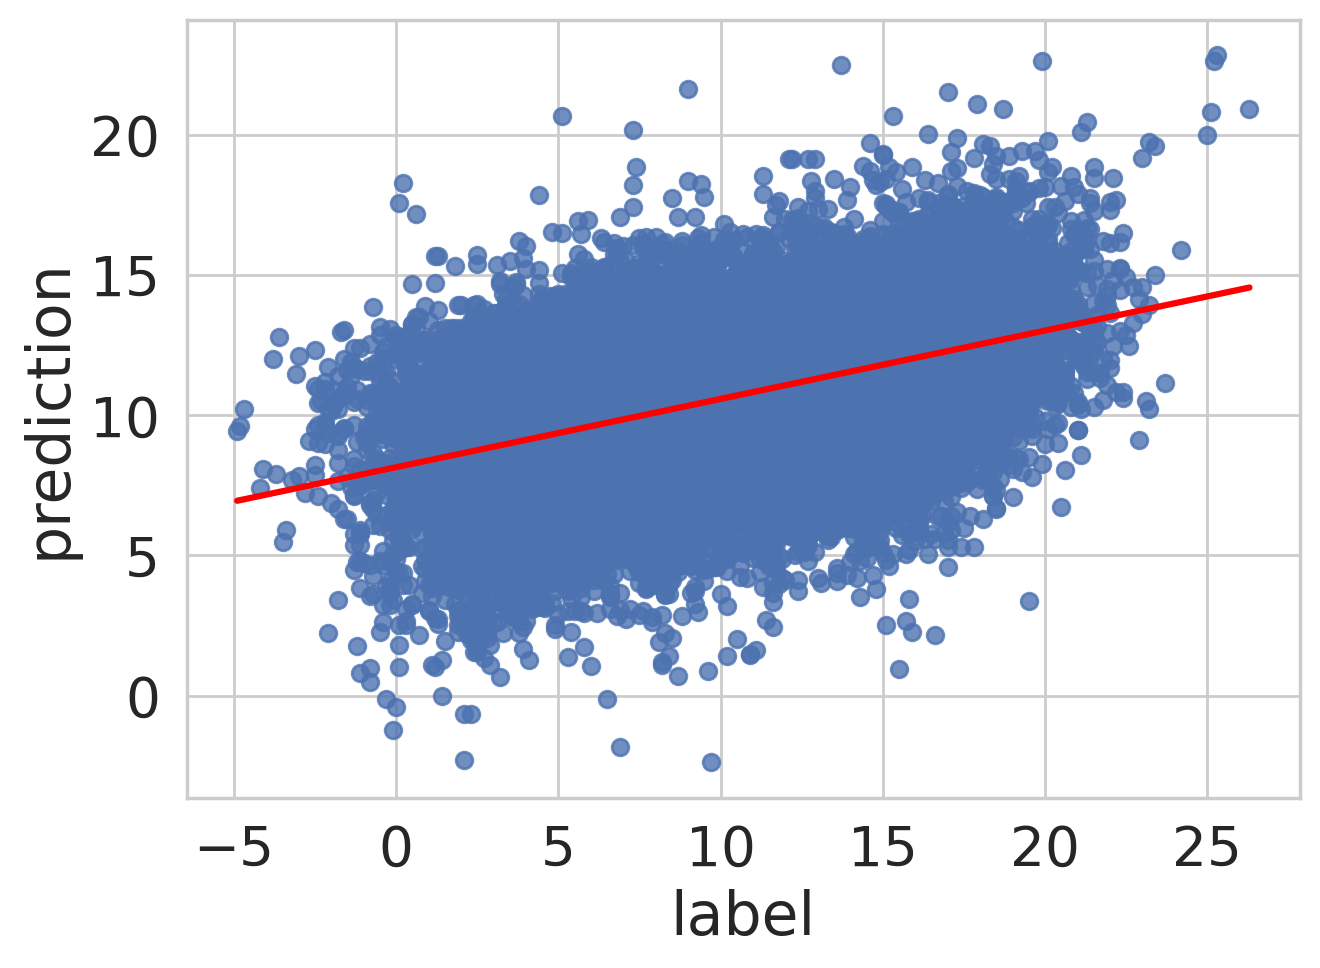

In [25]:
pred_pd = preds.toPandas()

import seaborn
from scipy.stats import *
seaborn.set(style="whitegrid", font_scale=1.8)

import matplotlib.pyplot as plt  # It's good practice to import matplotlib explicitly

fig, ax = plt.subplots()
seaborn.set(color_codes=True)
seaborn.set(rc={'figure.figsize': (20, 10)})

seaborn.regplot(x="label", y="prediction", fit_reg=False, ax=ax, data=pred_pd, scatter_kws={"color": "b"})
seaborn.regplot(x="label", y="prediction", scatter=False, ax=ax, data=pred_pd, line_kws={"color": "red"})

#### Experimenting with an MLP Model

Now you can experiment with a Multi-Layer Perceptron (MLP) model. Since Spark MLlib provides an MLP classifier you might need to transform your regression problem into a classification task by binning air_temperature into discrete categories (e.g., “low”, “medium”, “high”). For example:

1. Binning the Target Variable: Create a new column that bins air_temperature into categories.
   
2. Using MultilayerPerceptronClassifier: Define the layers for your neural network, where the input layer size matches the number of features, and the output layer size equals the number of temperature categories.



In [26]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.sql.functions import col 
from pyspark.ml.feature import QuantileDiscretizer 
from pyspark.ml.classification import MultilayerPerceptronClassifier

In [28]:
# Cast relevant columns to double 
df_numeric = indexed.withColumn("air_temperature", col("air_temperature").cast("double")) \
.withColumn("precipitation", col("precipitation").cast("double")) \
.withColumn("wind_from_direction", col("wind_from_direction").cast("double")) \
.withColumn("relative_humidity", col("relative_humidity").cast("double")) \
.withColumn("wind_speed", col("wind_speed").cast("double")) \
.withColumn("msl", col("msl").cast("double"))


In [29]:
# Bin air_temperature into 3 classes (for classification using MLP) 
discretizer = QuantileDiscretizer(numBuckets=3, inputCol="air_temperature", outputCol="binnedLabel") 
binned_df = discretizer.fit(df_numeric).transform(df_numeric)

In [30]:
# Rename binnedLabel to 'label' for use as the target 
binned_df = binned_df.withColumnRenamed("binnedLabel", "label")

In [31]:
# Prepare features by assembling selected numeric columns 
vectorAssembler = VectorAssembler( inputCols=['indexedTime', 'precipitation', 'wind_from_direction', 'relative_humidity', 'wind_speed', 'msl'], handleInvalid="skip", outputCol='features' ) 
vectorized_df = vectorAssembler.transform(binned_df)

In [32]:
# Select only the features and label for training 
dataset_class = vectorized_df.select("features", "label")
dataset_class.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[2667.0,0.3,190.0...|  1.0|
|[2668.0,0.2,220.0...|  0.0|
|[2669.0,0.0,190.0...|  0.0|
|[2670.0,0.0,190.0...|  0.0|
|[2671.0,0.0,220.0...|  0.0|
+--------------------+-----+
only showing top 5 rows



In [33]:
# Split the data 
(trainingData, testData) = dataset_class.randomSplit([0.7, 0.3])

In [34]:
# Define the MLP classifier; adjust the input layer size as per your features 
layers = [6, 12, 3] 
mlp = MultilayerPerceptronClassifier(maxIter=100, layers=layers, blockSize=128, seed=1234)

In [35]:
# Train the model 
model_mlp = mlp.fit(trainingData)

In [36]:
# Make predictions 
predictions_mlp = model_mlp.transform(testData) 
predictions_mlp.select("features", "label", "prediction").show(5)

+--------------------+-----+----------+
|            features|label|prediction|
+--------------------+-----+----------+
|(6,[0,5],[235850....|  2.0|       1.0|
|(6,[0,5],[235853....|  2.0|       1.0|
|(6,[0,5],[235860....|  2.0|       1.0|
|(6,[0,5],[235861....|  2.0|       1.0|
|[6.0,0.0,70.0,87....|  1.0|       0.0|
+--------------------+-----+----------+
only showing top 5 rows



In [39]:
# Evaluate using a suitable classification evaluator, e.g., accuracy 
from pyspark.ml.evaluation import MulticlassClassificationEvaluator 
evaluator = MulticlassClassificationEvaluator(metricName="accuracy") 
accuracy = evaluator.evaluate(predictions_mlp)
print (f"Accuracy: {accuracy}")

Accuracy: 0.3638091885231473


In [43]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction"
)  # No metricName specified initially

# Precision by class
precision = evaluator.evaluate(predictions_mlp, {evaluator.metricName: "weightedPrecision"})
print(f"Weighted Precision: {precision}")

# Recall by class
recall = evaluator.evaluate(predictions_mlp, {evaluator.metricName: "weightedRecall"})
print(f"Weighted Recall: {recall}")

# F1 score
f1 = evaluator.evaluate(predictions_mlp, {evaluator.metricName: "f1"})
print(f"F1 Score: {f1}")

# Accuracy (already calculated in the notebook)
accuracy = evaluator.evaluate(predictions_mlp, {evaluator.metricName: "accuracy"})
print(f"Accuracy: {accuracy}")

Weighted Precision: 0.4451755348161653
Weighted Recall: 0.36380918852314736
F1 Score: 0.21983022302979746
Accuracy: 0.3638091885231473


In [44]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# Convert predictions to Pandas DataFrame
predictions_pd = predictions_mlp.select("label", "prediction").toPandas()

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_class_0 = roc_auc_score(
    (predictions_pd["label"] == 0).astype(int),
    (predictions_pd["prediction"] == 0).astype(int),
    multi_class="ovr",
)
roc_auc_class_1 = roc_auc_score(
    (predictions_pd["label"] == 1).astype(int),
    (predictions_pd["prediction"] == 1).astype(int),
    multi_class="ovr",
)
roc_auc_class_2 = roc_auc_score(
    (predictions_pd["label"] == 2).astype(int),
    (predictions_pd["prediction"] == 2).astype(int),
    multi_class="ovr",
)

print(f"ROC AUC Class 0: {roc_auc_class_0}")
print(f"ROC AUC Class 1: {roc_auc_class_1}")
print(f"ROC AUC Class 2: {roc_auc_class_2}")

ROC AUC Class 0: 0.5069249426110377
ROC AUC Class 1: 0.5035708348914945
ROC AUC Class 2: 0.5062642125989195


In [45]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Parameter search space (example)
layers_options = [[6, 12, 3], [6, 12, 12, 3], [6, 24, 12, 3]]
maxIter_options = [50, 100, 200]

best_accuracy = 0
best_params = {}

for layers in layers_options:
    for maxIter in maxIter_options:
        mlp = MultilayerPerceptronClassifier(
            maxIter=maxIter, layers=layers, blockSize=128, seed=1234
        )
        model = mlp.fit(trainingData)
        predictions = model.transform(testData)
        evaluator = MulticlassClassificationEvaluator(metricName="accuracy")
        accuracy = evaluator.evaluate(predictions)

        print(f"Layers: {layers}, maxIter: {maxIter}, Accuracy: {accuracy}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = {"layers": layers, "maxIter": maxIter}

print(f"Best Accuracy: {best_accuracy}")
print(f"Best Parameters: {best_params}")

Layers: [6, 12, 3], maxIter: 50, Accuracy: 0.36292906178489703
Layers: [6, 12, 3], maxIter: 100, Accuracy: 0.3638091885231473
Layers: [6, 12, 3], maxIter: 200, Accuracy: 0.3668192219679634
Layers: [6, 12, 12, 3], maxIter: 50, Accuracy: 0.36180249955993665
Layers: [6, 12, 12, 3], maxIter: 100, Accuracy: 0.36537581411723286
Layers: [6, 12, 12, 3], maxIter: 200, Accuracy: 0.36615032564689315
Layers: [6, 24, 12, 3], maxIter: 50, Accuracy: 0.3637387783840873
Layers: [6, 24, 12, 3], maxIter: 100, Accuracy: 0.36329871501496214
Layers: [6, 24, 12, 3], maxIter: 200, Accuracy: 0.3651469811652878
Best Accuracy: 0.3668192219679634
Best Parameters: {'layers': [6, 12, 3], 'maxIter': 200}


In [46]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Parameter search space (example)
layers_options = [[6, 12, 3], [6, 12, 12, 3], [6, 24, 12, 3]]
maxIter_options = [50, 100, 200]

best_accuracy = 0
best_precision = 0
best_recall = 0
best_f1 = 0
best_params = {}

for layers in layers_options:
    for maxIter in maxIter_options:
        mlp = MultilayerPerceptronClassifier(
            maxIter=maxIter, layers=layers, blockSize=128, seed=1234
        )
        model = mlp.fit(trainingData)
        predictions = model.transform(testData)
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction"
        )  # Specify labelCol and predictionCol

        accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
        precision = evaluator.evaluate(
            predictions, {evaluator.metricName: "weightedPrecision"}
        )
        recall = evaluator.evaluate(
            predictions, {evaluator.metricName: "weightedRecall"}
        )
        f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

        print(f"Layers: {layers}, maxIter: {maxIter}")
        print(f"  Accuracy: {accuracy}")
        print(f"  Precision: {precision}")
        print(f"  Recall: {recall}")
        print(f"  F1: {f1}")

        if accuracy > best_accuracy:  # Or you can choose to optimize for F1, etc.
            best_accuracy = accuracy
            best_precision = precision
            best_recall = recall
            best_f1 = f1
            best_params = {"layers": layers, "maxIter": maxIter}

print("--- Best Results ---")
print(f"Best Accuracy: {best_accuracy}")
print(f"Best Precision: {best_precision}")
print(f"Best Recall: {best_recall}")
print(f"Best F1: {best_f1}")
print(f"Best Parameters: {best_params}")

Layers: [6, 12, 3], maxIter: 50
  Accuracy: 0.36292906178489703
  Precision: 0.4472398671852693
  Recall: 0.36292906178489703
  F1: 0.202976884223202
Layers: [6, 12, 3], maxIter: 100
  Accuracy: 0.3638091885231473
  Precision: 0.4451755348161653
  Recall: 0.36380918852314736
  F1: 0.21983022302979746
Layers: [6, 12, 3], maxIter: 200
  Accuracy: 0.3668192219679634
  Precision: 0.5029589719879428
  Recall: 0.3668192219679634
  F1: 0.22617277227586577
Layers: [6, 12, 12, 3], maxIter: 50
  Accuracy: 0.36180249955993665
  Precision: 0.43321215739469293
  Recall: 0.3618024995599366
  F1: 0.20970547144051105
Layers: [6, 12, 12, 3], maxIter: 100
  Accuracy: 0.36537581411723286
  Precision: 0.30071521352312114
  Recall: 0.3653758141172329
  F1: 0.2038636319219365
Layers: [6, 12, 12, 3], maxIter: 200
  Accuracy: 0.36615032564689315
  Precision: 0.6255771224455594
  Recall: 0.36615032564689315
  F1: 0.21278842014566712
Layers: [6, 24, 12, 3], maxIter: 50
  Accuracy: 0.3637387783840873
  Precision

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 8.249999999999973, 'Predicted Label')

Text(30.25, 0.5, 'True Label')

Text(0.5, 1.0, 'Confusion Matrix')

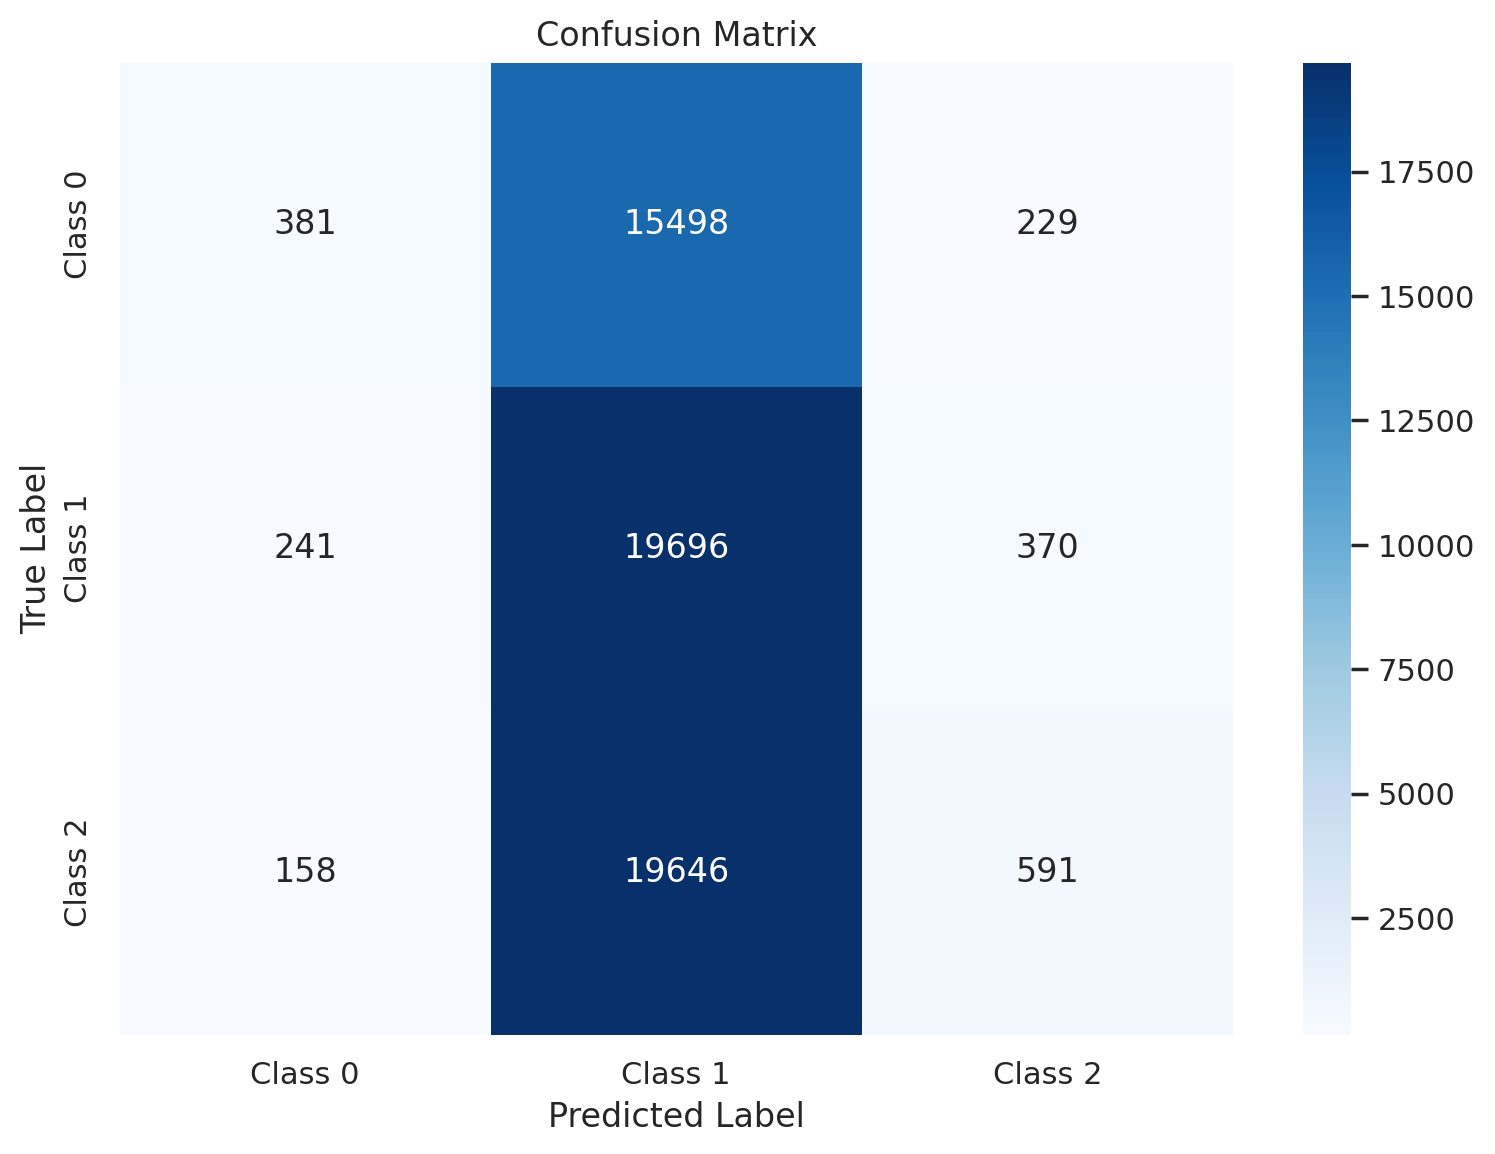

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'predictions_mlp' is your Spark DataFrame with 'label' and 'prediction'
predictions_pd = predictions_mlp.select("label", "prediction").toPandas()

# Calculate the confusion matrix
cm = confusion_matrix(predictions_pd["label"], predictions_pd["prediction"])

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()